# flow5 연결 · 도어 연동 확인

flow5 7.57의 실제 270조건을 공력표로 연결했다. 수납 트림은 받음각 **−1.327°**, 승강타 **2.930°**, 추력 **4.822 N**이다. 포획 실패 시 문이 **140° 열린 상태**를 유지하며, 정상 수락 상태를 저장해 재개할 수 있다.

이 노트북은 연결 검증 기록이다. flow5의 동체 공력, R3의 포획 성공, 전체 결합 안정성과 수치 수렴을 검증한 결과는 아니다.

## 입력과 해석 범위

공력은 `examples/h1_normal_r3_flow5.yaml`, 원본 해석 기록은 `test_models/H1_reference/runs/flow5_connection_01/aerodynamics`에 있다. 기체는 임시 R3 설계이며 실제 팀 기체 자료가 아니다.

- flow5: 동체를 제외한 VLM2, 후연 형상을 직접 회전한 조종면.
- 비교 AVL: 같은 R3 양력면이며 동체를 제외. 조종면은 법선 선형화 방식.
- 회전율: flow5가 출력한 종·횡방향 블록 사용. 출력되지 않는 교차항 0은 명시적 가정.
- 센서·줄·접촉·후류 입력: 기존 가정값. 추가 항력계수 0.035는 별도 적용.
- 도어 검증: 이전 AVL 계산의 9.70초 상태에서 11초까지 이어 계산. 전 과정 재실행과 구분한다.

근거: [공식 자동 실행 설명](https://github.com/techwinder/flow5/discussions/1), [7.57 힘·모멘트 축 구현](https://github.com/techwinder/flow5/blob/v7.57/flow5-lib/objects3d/analysis3d/aeroforces.cpp).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dbf_stability import load_case, AeroDatabase, solve_trim
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
RUN = ROOT/'test_models/H1_reference/runs/flow5_connection_01'
case = load_case(ROOT/'examples/h1_normal_r3_flow5.yaml')
aero = AeroDatabase(RUN/'aerodynamics/aero_database.npz')
plt.rcParams.update({'font.family':'Malgun Gothic','font.size':11,'axes.unicode_minus':False,
                     'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})
pd.Series({k:aero.metadata[k] for k in ['solver','condition_count','actual_solver_points','body_included','rate_derivative_closure']})

solver                                  flow5 flow5 v7.57
condition_count                                        54
actual_solver_points                                  270
body_included                                       False
rate_derivative_closure    classical_longitudinal_lateral
dtype: object

## 공력표에서 다시 계산한 트림

In [2]:
trim_rows = []
for mode in ['aircraft_only', 'stowed']:
    trim = solve_trim(case, aero, mode=mode)
    trim_rows.append({'상태':mode, '받음각 (deg)':trim['alpha_deg'],
                     '승강타 (deg)':trim['elevator_deg'], '추력 (N)':trim['thrust_N'],
                     '평형 잔차':trim['residual_norm']})
pd.DataFrame(trim_rows).round(6)

,상태,받음각 (deg),승강타 (deg),추력 (N),평형 잔차
0,aircraft_only,-1.341125,2.705899,4.817410,0.0
1,stowed,-1.326928,2.930295,4.821917,0.0


## AVL과 직접 비교한 공력

각 점은 실제 계산이다. 두 해석기의 차이는 정확도 오차가 아니며, 분할 방식과 조종면 모델도 서로 다르다. 아래 그래프는 옆미끄럼 0°, 승강타 0° 조건만 표시한다.

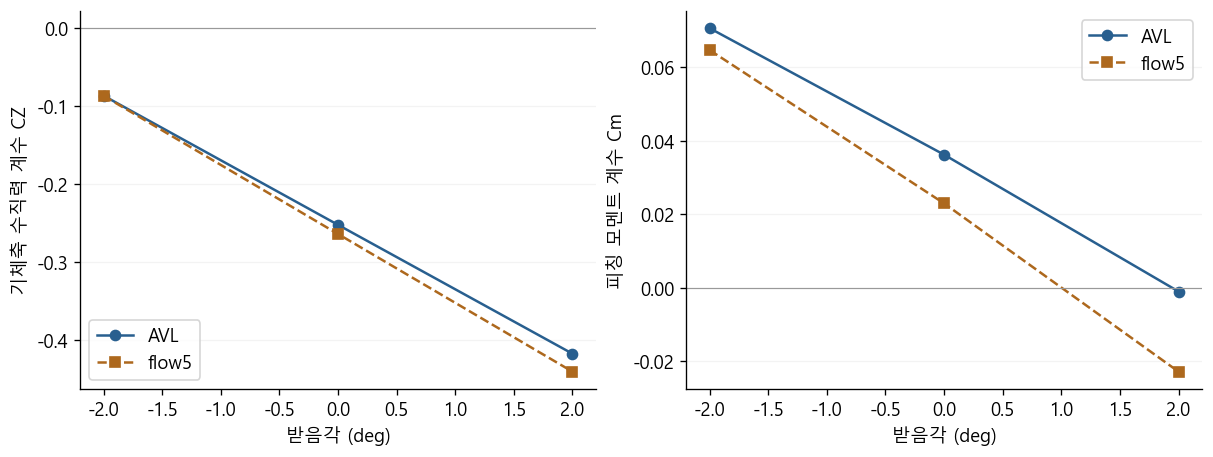

,alpha_deg,beta_deg,elevator_deg,difference_CZ,difference_Cm
0,-2,-4,0,0.000104,-0.006436
1,-2,0,0,-0.000227,-0.005942
2,-2,4,0,0.000104,-0.006435
3,0,-4,0,-0.011341,-0.013699
4,0,0,0,-0.011733,-0.013238
5,0,4,0,-0.011341,-0.013698
6,2,-4,0,-0.022585,-0.022198
7,2,0,0,-0.023026,-0.021779
8,2,4,0,-0.022585,-0.022196
9,0,0,-8,-0.026842,-0.052040


In [3]:
comparison = pd.read_csv(RUN/'avl_comparison/comparison.csv')
selected = comparison[(comparison.beta_deg==0)&(comparison.elevator_deg==0)].sort_values('alpha_deg')
fig, axes = plt.subplots(1,2,figsize=(10,3.7),layout='constrained')
for ax, coefficient, label in zip(axes, ['CZ','Cm'], ['기체축 수직력 계수 CZ','피칭 모멘트 계수 Cm']):
    for solver,color,style in [('avl','#285f8f','o-'),('flow5','#ad681d','s--')]:
        ax.plot(selected.alpha_deg,selected[f'{solver}_{coefficient}'],style,color=color,label=solver.upper() if solver=='avl' else solver)
    ax.set(xlabel='받음각 (deg)',ylabel=label);ax.axhline(0,color='#999',lw=.7);ax.grid(axis='y',alpha=.15);ax.legend()
plt.show()
comparison[['alpha_deg','beta_deg','elevator_deg','difference_CZ','difference_Cm']].round(6)

## 기체 단독 피치 응답

각 해석기로 구한 트림에서 피치만 +1° 바꾼 뒤 조종면·추력을 유지한다. 센서와 줄의 운동은 제외한 검사다. AVL 곡선은 동체 모델을 포함한 기존 계산이므로 공력 방법만 바꾼 대조 실험은 아니다.

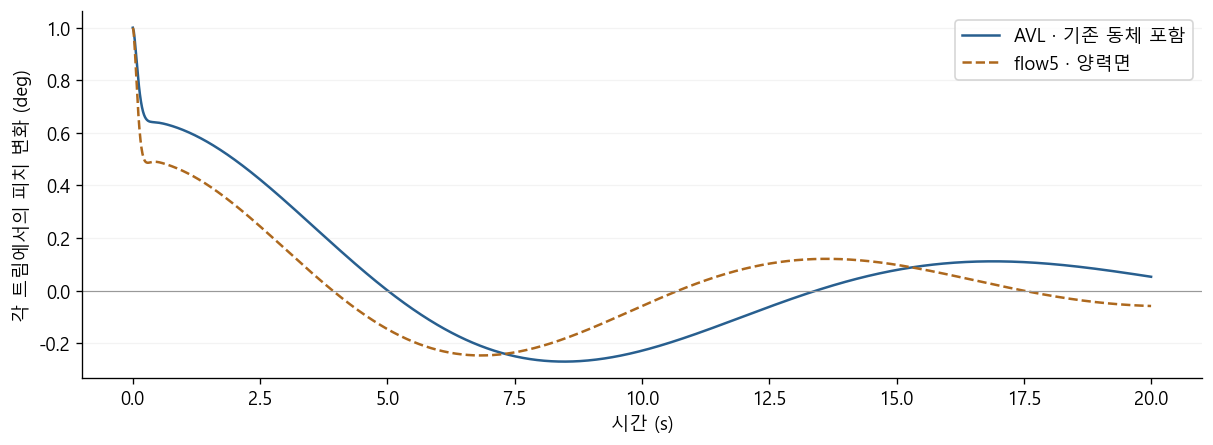

In [4]:
flow = pd.read_csv(RUN/'flow5_airframe_response/mission/timeseries.csv')
flow_trim = json.loads((RUN/'flow5_airframe_response/mission/trim.json').read_text())
old = ROOT/'test_models/H1_reference/runs/normal_r3_01/airframe_response/normal_r3'
avl = pd.read_csv(old/'timeseries.csv')
fig,ax=plt.subplots(figsize=(10,3.6),layout='constrained')
ax.plot(avl.time_s,avl.pitch_deg-(avl.pitch_deg.iloc[0]-1),label='AVL · 기존 동체 포함',color='#285f8f')
ax.plot(flow.time_s,flow.pitch_deg-flow_trim['alpha_deg'],label='flow5 · 양력면',color='#ad681d',ls='--')
ax.set(xlabel='시간 (s)',ylabel='각 트림에서의 피치 변화 (deg)');ax.axhline(0,color='#999',lw=.7);ax.grid(axis='y',alpha=.15);ax.legend();plt.show()

## 포획 실패와 도어 닫힘 연동

닫힘 명령이 들어와도 포획되지 않으면 실제 도어는 열린 채 유지된다. 포획 허용 범위는 기존 6mm·8°·0.15m/s를 유지했다. 아래 값은 9.70–11초 구간만의 결과다.

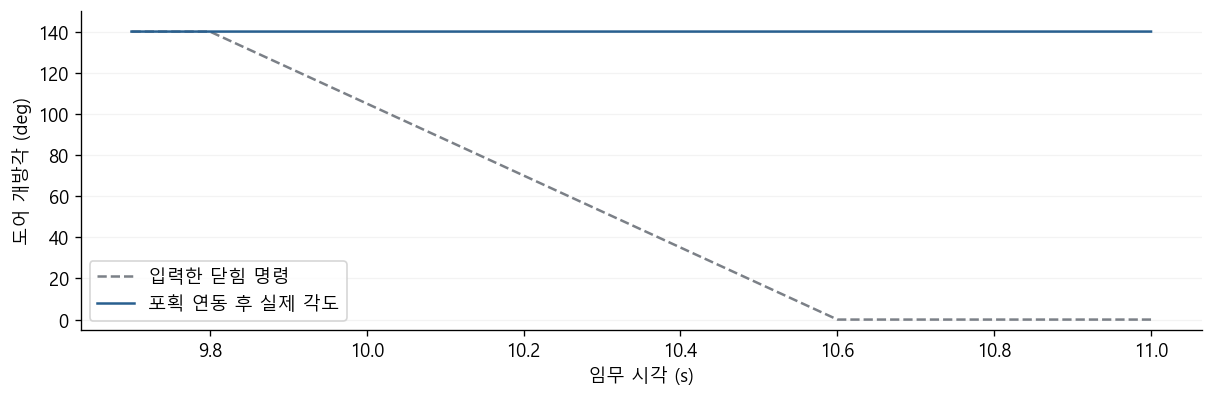

포획                False
종료 도어 (deg)       140.0
STEP 검사 시각 수        250
검사 시각에서 겹침            0
재개 위치·속도 연속        True
재개 도어 변화 (deg)      0.0
dtype: object

In [5]:
door = pd.read_csv(RUN/'door_interlock/mission/timeseries.csv')
door_summary = json.loads((RUN/'door_interlock/mission/summary.json').read_text(encoding='utf8'))
audit = json.loads((RUN/'door_interlock/mission/cad_collision_audit.json').read_text())
restart = json.loads((RUN/'door_interlock/restart_check.json').read_text())
fig,ax=plt.subplots(figsize=(10,3.2),layout='constrained')
ax.plot(door.time_s,door.door_command_deg,label='입력한 닫힘 명령',color='#7b8087',ls='--')
ax.plot(door.time_s,door.door_deg,label='포획 연동 후 실제 각도',color='#285f8f')
ax.set(xlabel='임무 시각 (s)',ylabel='도어 개방각 (deg)',ylim=(-5,150));ax.grid(axis='y',alpha=.15);ax.legend();plt.show()
pd.Series({'포획':door_summary['captured'],'종료 도어 (deg)':door_summary['final_door_deg'],
           'STEP 검사 시각 수':audit['samples'],'검사 시각에서 겹침':audit['intersecting_samples'],
           '재개 위치·속도 연속':restart['state_continuous'],'재개 도어 변화 (deg)':restart['door_continuous_deg']})

250개 선택 시각의 STEP 검사에서 겹침이 없었다. 모든 연속 시각의 무충돌을 입증한 검사는 아니다. 재개 체크포인트는 위치·속도 외에 포획 상태와 포획 시각을 보존한다.

## flow5 공력으로 계산한 센서 전개

0–3초의 문 개방·센서 방출·줄 전개를 계산했다. 실행 시간 한도로 멈춘 2.21494초에서 저장 상태를 그대로 이어 계산했다. 아래 그래프는 두 구간의 실제 저장값을 연결한 결과이며, 재개 경계의 위치·속도·자세와 물리 입력이 같은지 검사했다.

3초는 회수 시작 시각이므로 회수·포획 성공을 평가하는 구간은 아니다. 접촉 하중은 가정한 접촉 물성의 결과이며 시간 간격·줄 분할 수에 대한 수렴 확인도 남아 있다.

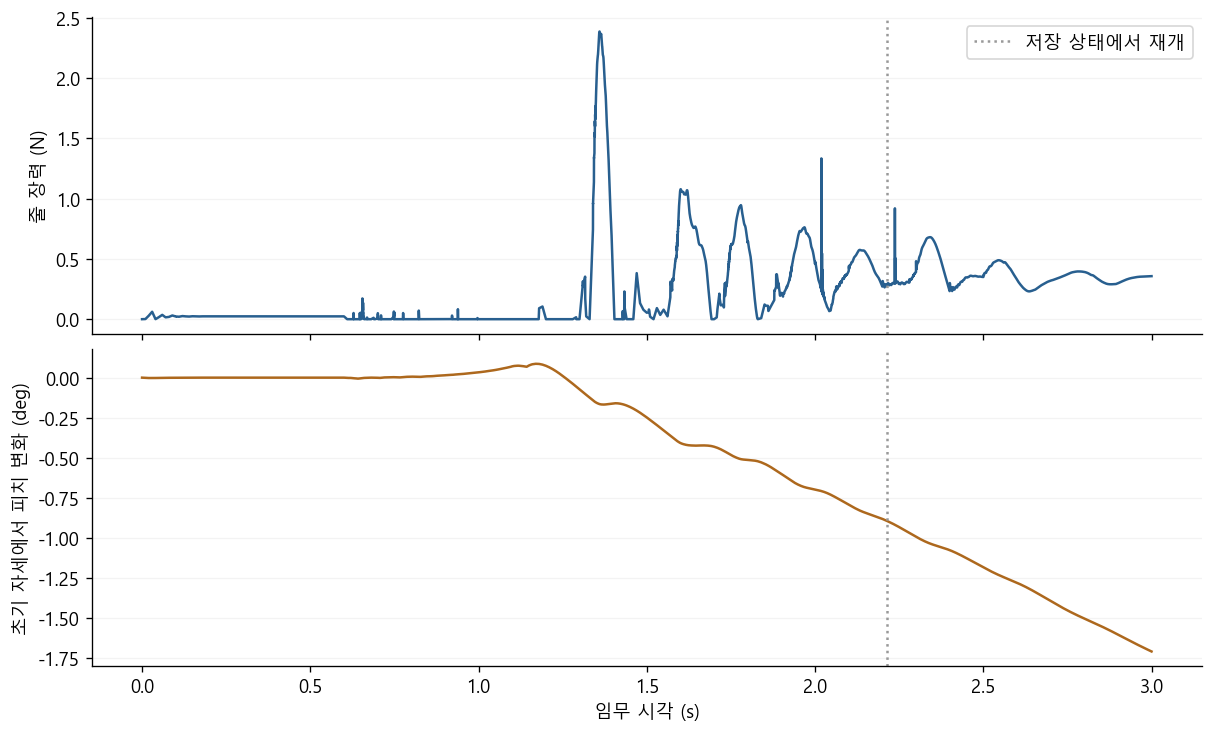

종료 시각 (s)                3.0
최대 줄 장력 (N)         2.387922
최대 피치 변화 (deg)      1.709751
최대 접촉력 (N, 미검증)    12.748903
재개 상태 연속                True
STEP 검사 시각 수             496
검사 시각에서 겹침                 0
STEP 검사 오류                 0
dtype: object

In [6]:
deployment = RUN/'flow5_deployment/combined'
trajectory = pd.read_csv(deployment/'timeseries.csv')
summary = json.loads((deployment/'summary.json').read_text(encoding='utf8'))
deployment_audit = json.loads((deployment/'cad_collision_audit.json').read_text())
fig,axes=plt.subplots(2,1,figsize=(10,6),sharex=True,layout='constrained')
axes[0].plot(trajectory.time_s,trajectory.tension_N,color='#285f8f')
axes[0].set(ylabel='줄 장력 (N)')
axes[1].plot(trajectory.time_s,trajectory.pitch_deg-trajectory.pitch_deg.iloc[0],color='#ad681d')
axes[1].set(xlabel='임무 시각 (s)',ylabel='초기 자세에서 피치 변화 (deg)')
for ax in axes:
    ax.axvline(2.2149415214566774,color='#999',ls=':',label='저장 상태에서 재개')
    ax.grid(axis='y',alpha=.15)
axes[0].legend();plt.show()
pd.Series({'종료 시각 (s)':summary['end_time_s'], '최대 줄 장력 (N)':summary['max_tension_N'],
           '최대 피치 변화 (deg)':summary['max_pitch_change_deg'],
           '최대 접촉력 (N, 미검증)':summary['max_contact_N'],
           '재개 상태 연속':summary['restart_state_continuous'],
           'STEP 검사 시각 수':deployment_audit['samples'],
           '검사 시각에서 겹침':deployment_audit['intersecting_samples'],
           'STEP 검사 오류':deployment_audit['cad_query_error_samples']})

## 재실행

`aero.backend: flow5`로 해석기를 선택한다. 아래 명령은 새 공력표를 실제 생성하므로 필요할 때 별도 터미널에서 실행한다.

```powershell
.venv/Scripts/python -m dbf_stability.cli build-aero --case examples/h1_normal_r3_flow5.yaml --aero outputs/flow5_new/aero_database.npz --workers 4
.venv/Scripts/python -m dbf_stability.cli simulate --case examples/h1_normal_r3_flow5.yaml --aero outputs/flow5_new/aero_database.npz --duration 3 --output outputs/flow5_new/deployment
```

중단 뒤에는 `resume` 명령에 `--checkpoint`, `--duration`, 새 `--output`을 지정한다. 물리 입력·형상·공력표·계산 소스가 달라지면 재개를 거부한다. 자세한 내용은 `docs/FLOW5_CONNECTION.md`에 있다.

다음 물리 모델 과제는 센서 정렬·포획부와 내부 가이드가 포함된 견인 평형이다. 이 노트북의 기체 단독 안정성을 센서 결합 안정성으로 해석하면 안 된다.